<a href="https://colab.research.google.com/github/nulahaa-cpu/AIFFEL_quest_cr/blob/main/Exploration/Ex14/Part3_LoRA_%EC%9E%AC%EC%8B%A4%ED%96%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 Part 3 재실행 — Checkpoint + LoRA (약 10분)

앞서 실행한 본 노트북에서 LoRA 저장소가 삭제되어 LoRA 없이 진행됐던 부분만 다시 돌리는 미니 노트북입니다.
Part 1(보간)·Part 2(Dreambooth) 결과는 기존 노트북 출력에 저장되어 있으므로 다시 실행할 필요 없습니다.

> **시작 전 필수!** `런타임 → 런타임 유형 변경 → T4 GPU` 선택

In [1]:
!pip install -q -U "diffusers==0.39.0" "transformers==5.14.1" accelerate peft safetensors
!nvidia-smi -L

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 60.7 MB/s eta 0:00:00
GPU 0: Tesla T4 (UUID: GPU-ca9e1fe2-3c50-f3d5-8ba9-99c84a9af882)


In [2]:
import gc

import numpy as np
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
assert device == "cuda", "⚠️ 런타임 → 런타임 유형 변경 → T4 GPU 를 선택해주세요!"

SEED = 42


def image_grid(imgs, rows, cols, titles=None, size=3):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < len(imgs):
            ax.imshow(imgs[i])
            if titles:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    plt.show()


# 지난 실행에서 로드에 성공했던 수업 자료 checkpoint (실패 시 DreamShaper 로 폴백)
CKPT_CANDIDATES = [
    "digiplay/hellofantasytime_v1.22",
    "Lykon/dreamshaper-8",
]

pipe_style, CKPT_ID = None, None
for ckpt in CKPT_CANDIDATES:
    try:
        pipe_style = StableDiffusionPipeline.from_pretrained(
            ckpt, torch_dtype=dtype, safety_checker=None
        )
        CKPT_ID = ckpt
        break
    except Exception as e:
        print(f"'{ckpt}' 로드 실패({type(e).__name__}) → 다음 후보 시도")

assert pipe_style is not None, "checkpoint 로드에 모두 실패했습니다."
pipe_style = pipe_style.to(device)
pipe_style.enable_attention_slicing()
print("사용 checkpoint:", CKPT_ID)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/598 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


사용 checkpoint: digiplay/hellofantasytime_v1.22


In [3]:
# LoRA 로드 — 현재 살아있는 것으로 확인된 SD1.5 계열 포켓몬 LoRA (순서대로 시도)
LORA_CANDIDATES = [
    ("juliensimon/stable-diffusion-v1-5-pokemon-lora", "pytorch_lora_weights.safetensors"),
    ("pcuenq/pokemon-lora", "pytorch_lora_weights.bin"),
]

lora_ok = False
for repo, wname in LORA_CANDIDATES:
    try:
        pipe_style.unload_lora_weights()
        pipe_style.load_lora_weights(repo, weight_name=wname)
        print("LoRA 로드 성공:", repo)
        lora_ok = True
        break
    except Exception as e:
        print(f"{repo} 실패({type(e).__name__}) → 다음 후보 시도")

assert lora_ok, "LoRA 로드에 모두 실패했습니다."

# 💡 CivitAI 등에서 직접 받은 .safetensors 파일을 쓰는 경우:
# pipe_style.load_lora_weights(".", weight_name="lora_weight.safetensors")

pytorch_lora_weights.safetensors: reconstructing file:   0%|          |  0.00B / 3.23MB            

pytorch_lora_weights.safetensors: downloading bytes:           |  0.00B            

No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


LoRA 로드 성공: juliensimon/stable-diffusion-v1-5-pokemon-lora


In [7]:
!pip uninstall -q -y torchao

In [8]:
# LoRA 로드 (구버전 포맷 자동 변환 포함)
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file


def convert_legacy_lora(sd):
    """옛 diffusers(attn-procs) 포맷 → 현행 peft 포맷 키 변환"""
    new = {}
    for k, v in sd.items():
        nk = k.replace(".processor.", ".")
        nk = nk.replace("to_out_lora.down.weight", "to_out.0.lora_A.weight")
        nk = nk.replace("to_out_lora.up.weight", "to_out.0.lora_B.weight")
        for p in ["to_q", "to_k", "to_v"]:
            nk = nk.replace(f"{p}_lora.down.weight", f"{p}.lora_A.weight")
            nk = nk.replace(f"{p}_lora.up.weight", f"{p}.lora_B.weight")
        if not nk.startswith(("unet.", "text_encoder.")):
            nk = "unet." + nk
        new[nk] = v
    return new


f = hf_hub_download("juliensimon/stable-diffusion-v1-5-pokemon-lora",
                    "pytorch_lora_weights.safetensors")
state_dict = load_file(f)
print("원본 키 예시:", next(iter(state_dict)))

# 옛 포맷이면 변환
if any("_lora.down" in k or "_lora.up" in k for k in state_dict):
    state_dict = convert_legacy_lora(state_dict)
    print("→ 옛 포맷 감지, 변환 완료:", next(iter(state_dict)))

pipe_style.unload_lora_weights()
pipe_style.load_lora_weights(state_dict, adapter_name="pokemon")

# 지난번처럼 조용히 무시되는 일이 없도록, LoRA 레이어가 실제로 붙었는지 검사
assert any("lora_A" in n for n, _ in pipe_style.unet.named_modules()), "LoRA 적용 실패!"
print("✅ LoRA 실제 적용 확인 완료 — 이제 scale 비교 셀을 다시 실행하세요!")

원본 키 예시: down_blocks.0.attentions.0.transformer_blocks.0.attn1.processor.to_k_lora.down.weight
→ 옛 포맷 감지, 변환 완료: unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.lora_A.weight


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ LoRA 실제 적용 확인 완료 — 이제 scale 비교 셀을 다시 실행하세요!


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

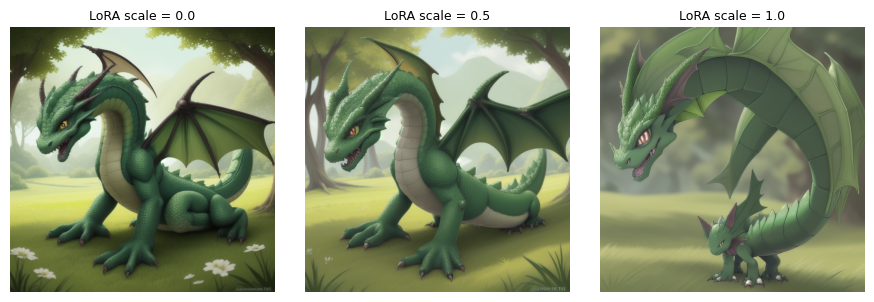

In [9]:
# LoRA 반영 강도(scale) 비교 — 같은 시드, scale 만 변경 (루브릭 ③ 증거)
prompt = "a cute dragon creature in a green field, best quality, highly detailed"

scales = [0.0, 0.5, 1.0]
images, titles = [], []
for s in scales:
    g = torch.Generator(device=device).manual_seed(SEED)
    img = pipe_style(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        cross_attention_kwargs={"scale": s},  # LoRA 반영 강도 (0=끔, 1=최대)
        generator=g,
    ).images[0]
    images.append(img)
    titles.append(f"LoRA scale = {s}")

image_grid(images, 1, len(scales), titles=titles)

  0%|          | 0/30 [00:00<?, ?it/s]

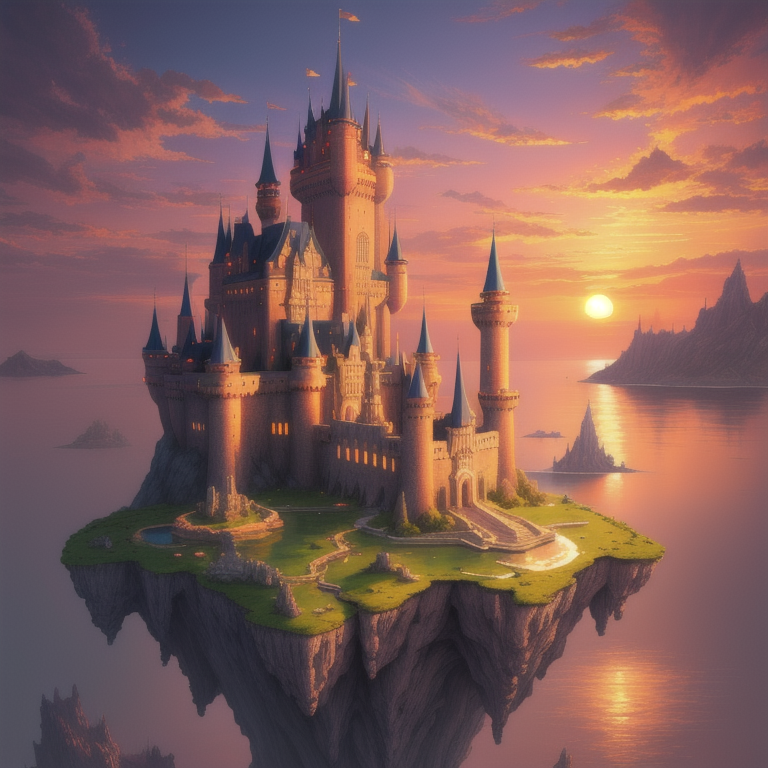

In [5]:
# 🎨 자유 생성 — checkpoint + LoRA 조합으로 나만의 이미지
my_prompt = "a majestic castle on a floating island, sunset, fantasy art"  # ✏️ 수정
negative = "low quality, blurry, watermark, text"
my_seed = 1234
lora_scale = 0.8

g = torch.Generator(device=device).manual_seed(my_seed)
img = pipe_style(
    my_prompt,
    negative_prompt=negative,
    num_inference_steps=30,
    guidance_scale=7.5,
    cross_attention_kwargs={"scale": lora_scale},
    generator=g,
).images[0]
img

### ✅ 제출 정리

이 노트북의 결과(scale 0.0 → 1.0 에서 그림체가 변하는 비교 + 자유 생성 이미지)가 **루브릭 ③ "Checkpoint 와 LoRA 를 다운로드하고 파이프라인을 구축하여 이미지 생성"** 의 증거가 됩니다.

- 루브릭 ①(보간 분석), ②(Dreambooth)는 기존 노트북의 저장된 출력으로 이미 충족
- 이 노트북을 기존 노트북과 같은 폴더에 함께 올리거나, 결과 이미지를 기존 노트북 Part 3 아래에 정리해 제출하세요